IMPORT LIBRARY AND  LOAD Dataset

In [44]:
# import the libraries we need
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report
# load the iris dataset
iris = load_iris()

# put it into a pandas dataframe so its easier to work with
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# add the species column (currently just numbers 0,1,2)
df['species'] = iris.target

# convert numbers to actual species names
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# check the first 5 rows
df.head()




,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [9]:
df.shape

(150, 5)

In [10]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

In [16]:
df.mean

<bound method DataFrame.mean of      sepal length (cm)  sepal width (cm)  ...  petal width (cm)    species
0                  5.1               3.5  ...               0.2     setosa
1                  4.9               3.0  ...               0.2     setosa
2                  4.7               3.2  ...               0.2     setosa
3                  4.6               3.1  ...               0.2     setosa
4                  5.0               3.6  ...               0.2     setosa
..                 ...               ...  ...               ...        ...
145                6.7               3.0  ...               2.3  virginica
146                6.3               2.5  ...               1.9  virginica
147                6.5               3.0  ...               2.0  virginica
148                6.2               3.4  ...               2.3  virginica
149                5.9               3.0  ...               1.8  virginica

[150 rows x 5 columns]>

In [15]:
df.min()


sepal length (cm)       4.3
sepal width (cm)        2.0
petal length (cm)       1.0
petal width (cm)        0.1
species              setosa
dtype: object

In [17]:
df.max()

sepal length (cm)          7.9
sepal width (cm)           4.4
petal length (cm)          6.9
petal width (cm)           2.5
species              virginica
dtype: object

In [18]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [20]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

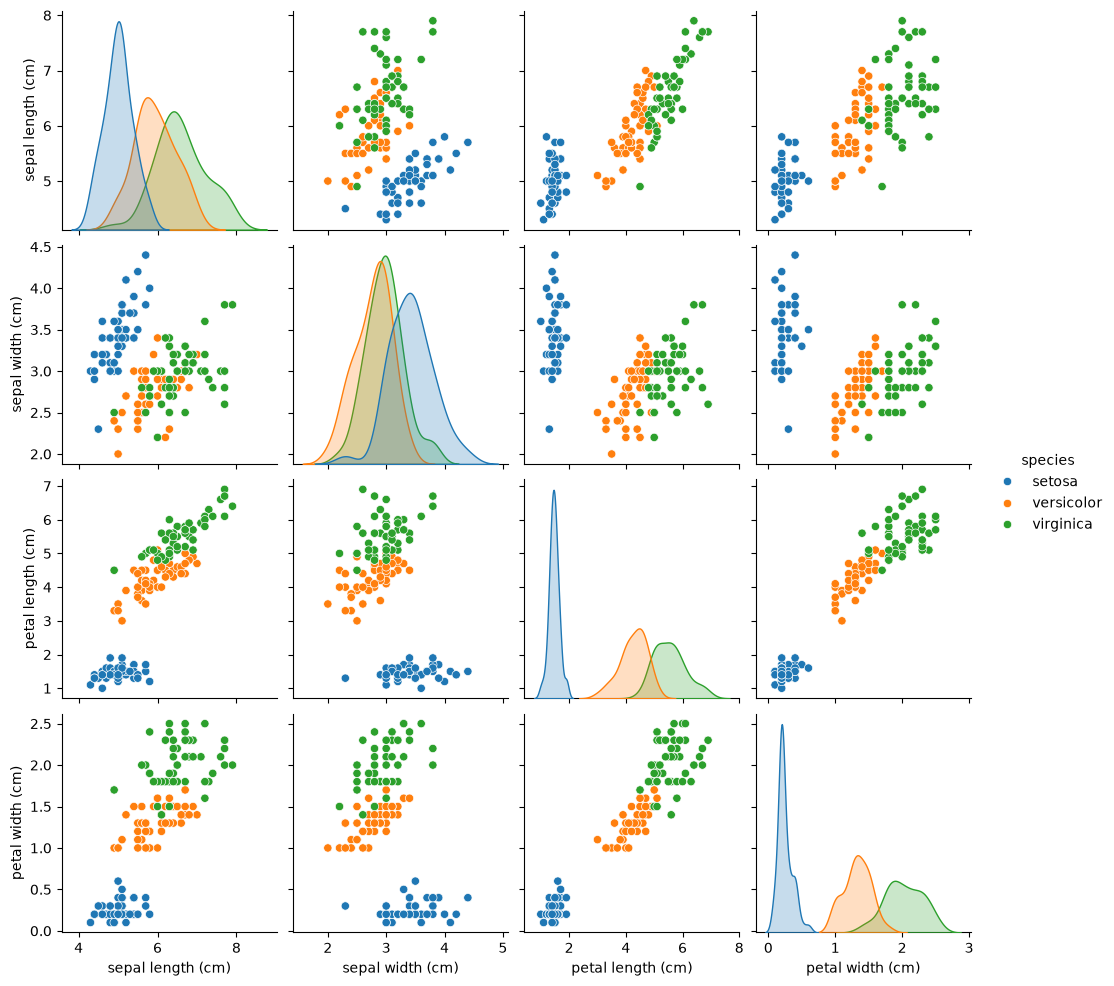

In [24]:
sns.pairplot(data=df, hue='species')

### Feature Selection Discussion

Looking at the pairplot, **petal length** and **petal width** are clearly the most 
discriminative features for classifying iris species. In any plot involving these 
two measurements, the setosa species (blue) forms a completely isolated cluster, 
while versicolor (orange) and virginica (green) are mostly separable with only 
minor overlap.

In contrast, **sepal length** and **sepal width** show significant overlap between 
all three species, making them much weaker predictors on their own.

Based on this, petal measurements should carry more weight in classification 
than sepal measurements, though all four features will still be used in the 
models to let the algorithms learn the relationships automatically.

<Axes: xlabel='species', ylabel='sepal length (cm)'>

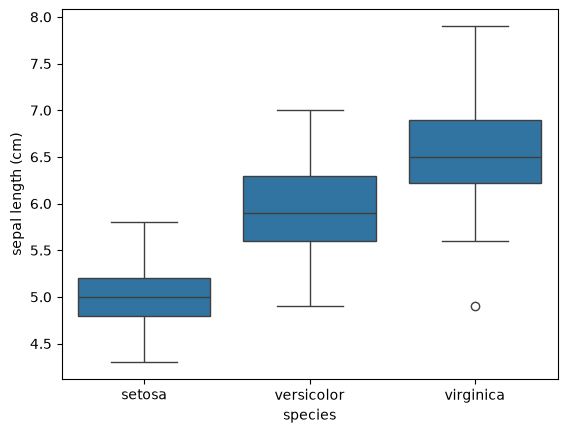

In [27]:
sns.boxplot(data=df, x='species', y='sepal length (cm)')

<Axes: xlabel='species', ylabel='petal length (cm)'>

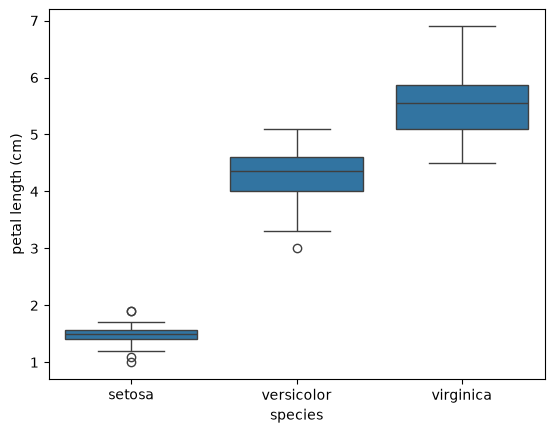

In [28]:
sns.boxplot(data=df,x='species',y='petal length (cm)')

<Axes: xlabel='species', ylabel='sepal width (cm)'>

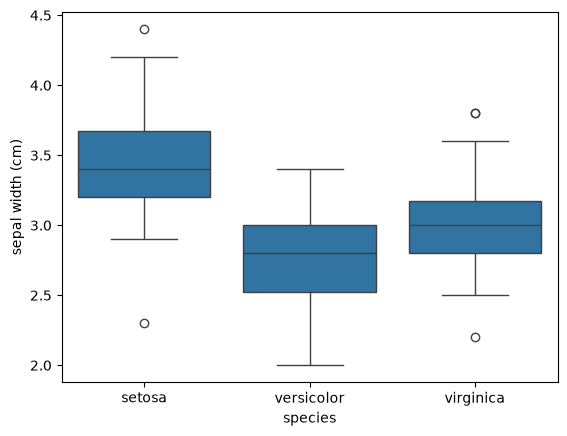

In [30]:
sns.boxplot(data=df, x='species', y='sepal width (cm)')

<Axes: xlabel='species', ylabel='petal width (cm)'>

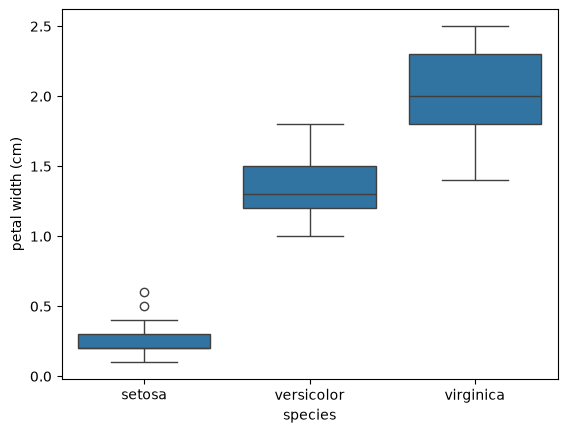

In [32]:
sns.boxplot(data=df, x='species',y='petal width (cm)')

Logisitic Regression

In [50]:
X = df.drop('species', axis=1)
Y = df['species']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

model_lr = LogisticRegression()
model_lr.fit(X_train, Y_train)
prediction_lr = model_lr.predict(X_test)
accuracy_lr = accuracy_score(Y_test, prediction_lr)
print(accuracy_lr)

0.9666666666666667


In [51]:
print(confusion_matrix(Y_test, prediction_lr))


[[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]


In [52]:
print(classification_report(Y_test, prediction_lr))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      0.92      0.96        13
   virginica       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



MODEL 2 K NEIGHBOURS 

In [54]:
from sklearn.neighbors import KNeighborsClassifier
X = df.drop('species', axis=1)
Y = df['species']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

model_knn = KNeighborsClassifier()
model_knn.fit(X_train, Y_train)
prediction_knn = model_knn.predict(X_test)
accuracy_knn = accuracy_score(Y_test, prediction_knn)
print(accuracy_knn)


1.0


In [55]:
print(confusion_matrix(Y_test, prediction_knn))


[[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


In [56]:
print(classification_report(Y_test, prediction_knn))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        11
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00         6

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Model Comparison & Conclusion

Two classifiers were trained and evaluated on the Iris dataset: Logistic Regression 
and K-Nearest Neighbors (KNN).

- **Logistic Regression** achieved an accuracy of [96]%, 
- **K-Nearest Neighbors** achieved an accuracy of [100]%


**Final choice:**K-Nearest Neighbors*  is selected as the best-performing model for this task, due to accuracy